In [3]:
# =========================================================
# HYBRID IDS: PSO + NEGATIVE SELECTION AIS + MLP + RF + XGBOOST + ENSEMBLE
# Dataset: UNSW_NB15
# Google Colab Full Implementation (PIPELINE PRESERVED + SMOTE + TOMEK + ADR)
# =========================================================

# =========================================================
# Step 1: Import Libraries
# =========================================================
import os
import random
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    balanced_accuracy_score,
    roc_curve,
    auc,
    precision_recall_curve
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Install xgboost if needed
try:
    from xgboost import XGBClassifier
except:
    !pip install -q xgboost
    from xgboost import XGBClassifier

# Install imbalanced-learn if needed
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.combine import SMOTETomek
except:
    !pip install -q imbalanced-learn
    from imblearn.over_sampling import SMOTE
    from imblearn.combine import SMOTETomek

np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

sns.set(style="whitegrid")

print("✅ Libraries imported successfully!")

# =========================================================
# Step 2: Mount Google Drive
# =========================================================
from google.colab import drive
drive.mount('/content/drive')

# =========================================================
# Step 3: Load UNSW_NB15 Dataset
# =========================================================
dataset_path = '/content/drive/MyDrive/Computational_Intelligence/UNSW_NB15'

files = os.listdir(dataset_path)
print("Available files:", files)

train_file = None
test_file = None

for f in files:
    fname = f.lower()
    if ('train' in fname or 'training' in fname) and f.endswith('.csv'):
        train_file = f
    elif ('test' in fname or 'testing' in fname) and f.endswith('.csv'):
        test_file = f

if train_file is None or test_file is None:
    raise FileNotFoundError("Train/Test CSV files not found in the UNSW_NB15 folder.")

train_df = pd.read_csv(os.path.join(dataset_path, train_file))
test_df = pd.read_csv(os.path.join(dataset_path, test_file))

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
print("\nTrain columns:\n", train_df.columns.tolist())


✅ Libraries imported successfully!
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Available files: ['UNSW_NB15_testing-set.csv', 'UNSW_NB15_training-set.csv']
Train shape: (175341, 45)
Test shape : (82332, 45)

Train columns:
 ['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']



Train binary distribution:
binary_label
1    119341
0     56000
Name: count, dtype: int64

Test binary distribution:
binary_label
1    45332
0    37000
Name: count, dtype: int64

Train: (140272, 42)
Val  : (35069, 42)
Test : (82332, 42)

Applying SMOTE + Tomek Links on training set...
Class counts before SMOTETomek:
Counter({np.int64(1): 95472, np.int64(0): 44800})
Using SMOTE k_neighbors = 5
Before SMOTETomek: (140272, 42) 140272
After  SMOTETomek: (189700, 42) 189700
Class counts after SMOTETomek:
Counter({np.int64(1): 94850, np.int64(0): 94850})

Starting PSO...
Iteration 1/25, Best Fitness: 0.9264
Iteration 2/25, Best Fitness: 0.9265
Iteration 3/25, Best Fitness: 0.9270
Iteration 4/25, Best Fitness: 0.9297
Iteration 5/25, Best Fitness: 0.9297
Iteration 6/25, Best Fitness: 0.9297
Iteration 7/25, Best Fitness: 0.9297
Iteration 8/25, Best Fitness: 0.9297
Iteration 9/25, Best Fitness: 0.9297
Iteration 10/25, Best Fitness: 0.9297
Iteration 11/25, Best Fitness: 0.9300
Iteration 12/25, B

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         6,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,409 (193.00 KB)

 Trainable params: 49,409 (193.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/80
1483/1483 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8543 - loss: 0.2866 - val_accuracy: 0.9104 - val_loss: 0.1926
Epoch 2/80
1483/1483 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9104 - loss: 0.1917 - val_accuracy: 0.9194 - val_loss: 0.1747
Epoch 3/80
1483/1483 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9191 - loss: 0.1757 - val_accuracy: 0.9213 - val_loss: 0.1704
Epoch 4/80
1483/1483 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9208 - loss: 0.1695 - val_accuracy: 0.9245 - val_loss: 0.1569
Epoch 5/80
1483/1483 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9235 - loss: 0.1650 - val_accuracy: 0.9267 - val_loss: 0.1522
Epoch 6/80
1483/1483 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9258 - loss: 0.1618 - val_accuracy: 0.9283 - val_loss: 0.1563
Epoch 7/80
1483/1483 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9260 - loss: 0.1600 - val_accuracy: 0.9280 - val_loss: 0.1512
Epoch 8/80
1483/1483 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9269 - loss: 0.1577 - 

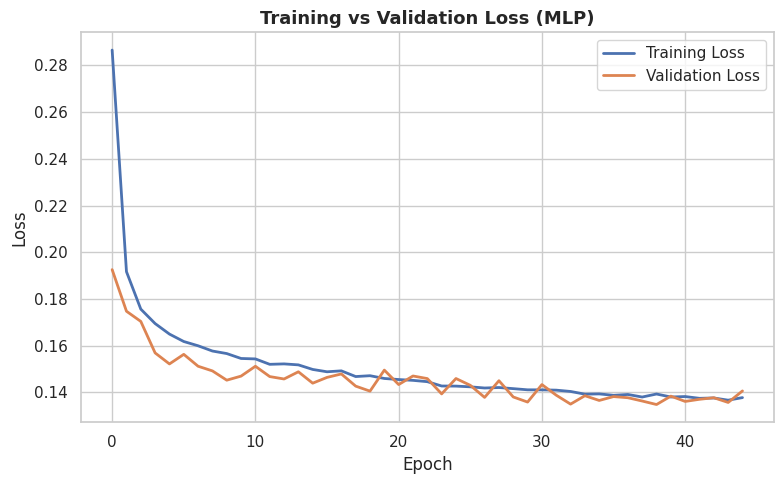

1096/1096 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

Best MLP threshold: 0.32
2573/2573 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step

HYBRID AIS + PSO + MLP
Accuracy              : 0.8783
Precision             : 0.8278
Recall                : 0.9836
F1-score              : 0.8990
Balanced Accuracy     : 0.8665
Attack Detection Rate : 0.9836
False Positive Rate   : 0.2507
True Negative Rate    : 0.7493

Confusion Matrix:
[[27723  9277]
 [  742 44590]]


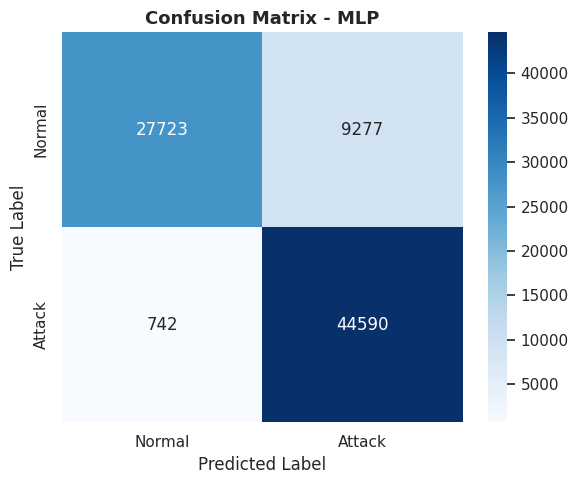

Best RF threshold : 0.34

HYBRID AIS + PSO + RANDOM FOREST
Accuracy              : 0.8552
Precision             : 0.7966
Recall                : 0.9897
F1-score              : 0.8827
Balanced Accuracy     : 0.8401
Attack Detection Rate : 0.9897
False Positive Rate   : 0.3096
True Negative Rate    : 0.6904

Confusion Matrix:
[[25546 11454]
 [  468 44864]]


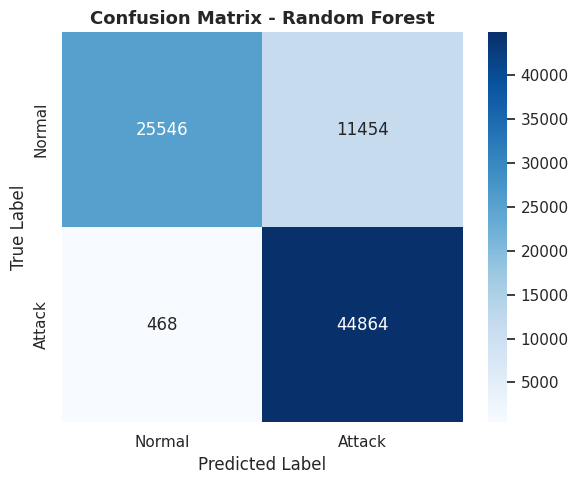

Best XGB threshold: 0.38

HYBRID AIS + PSO + XGBOOST
Accuracy              : 0.8652
Precision             : 0.8087
Recall                : 0.9892
F1-score              : 0.8899
Balanced Accuracy     : 0.8513
Attack Detection Rate : 0.9892
False Positive Rate   : 0.2866
True Negative Rate    : 0.7134

Confusion Matrix:
[[26395 10605]
 [  491 44841]]


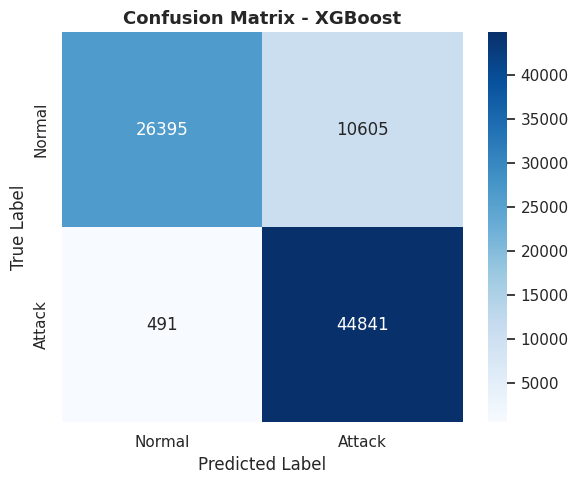


HYBRID AIS + PSO + ENSEMBLE VOTING
Accuracy              : 0.8637
Precision             : 0.8061
Recall                : 0.9908
F1-score              : 0.8889
Balanced Accuracy     : 0.8494
Attack Detection Rate : 0.9908
False Positive Rate   : 0.2920
True Negative Rate    : 0.7080

Confusion Matrix:
[[26195 10805]
 [  418 44914]]


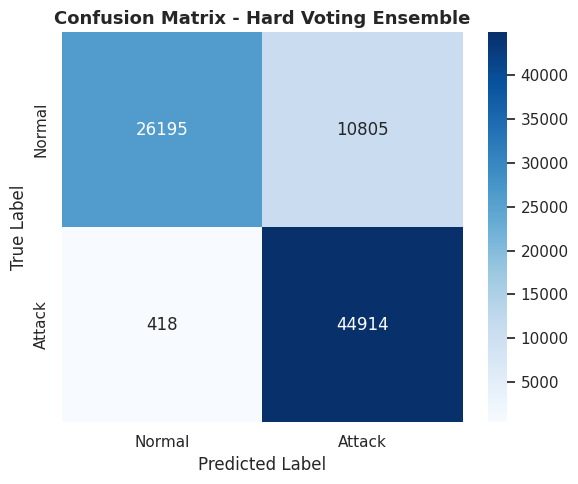


Best Soft Voting threshold: 0.38

HYBRID AIS + PSO + SOFT VOTING ENSEMBLE
Accuracy              : 0.8657
Precision             : 0.8090
Recall                : 0.9898
F1-score              : 0.8903
Balanced Accuracy     : 0.8517
Attack Detection Rate : 0.9898
False Positive Rate   : 0.2864
True Negative Rate    : 0.7136

Confusion Matrix:
[[26404 10596]
 [  464 44868]]


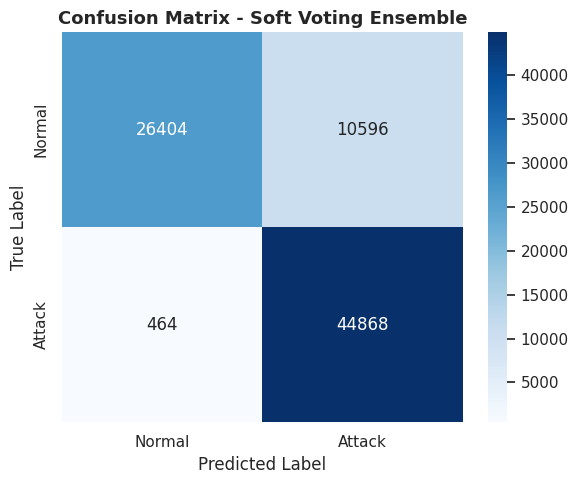

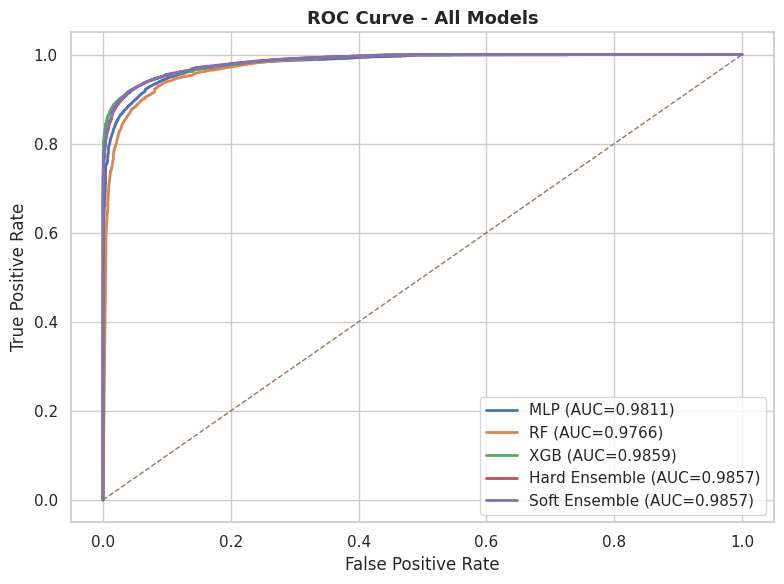

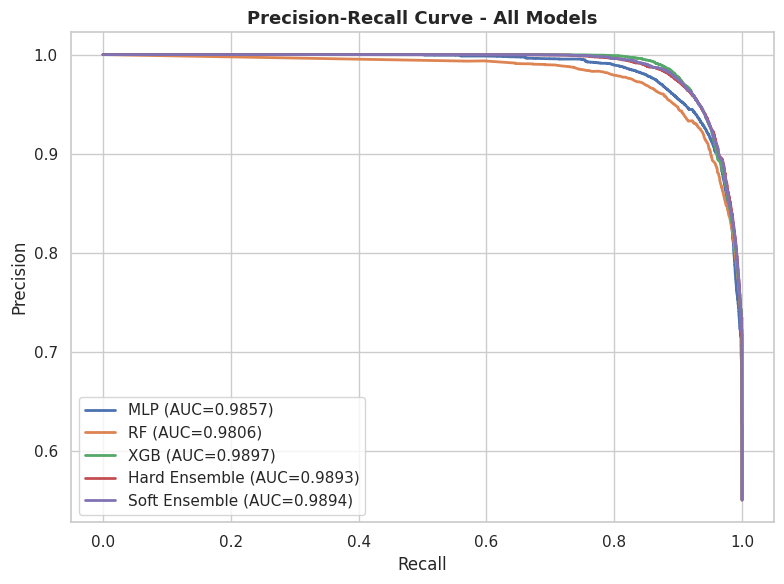

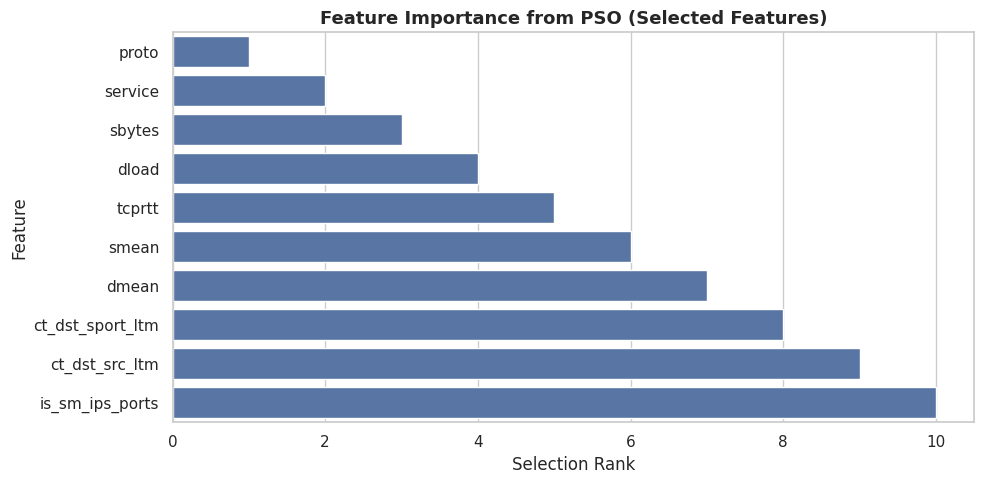

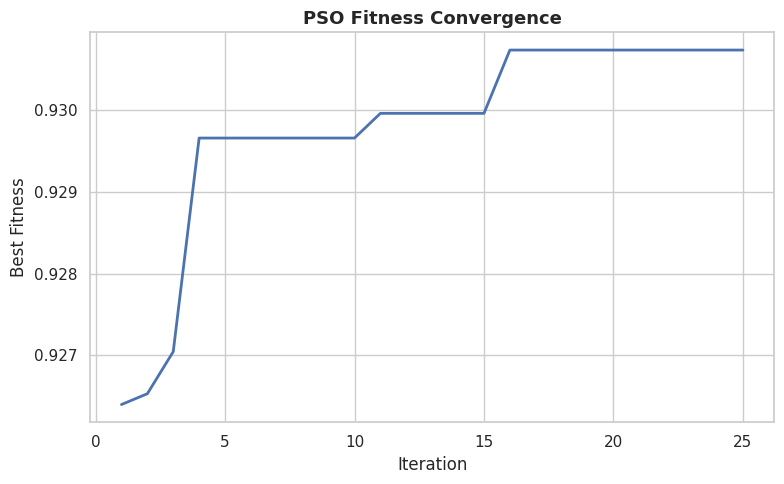


FINAL RESULTS SUMMARY
                  Model  Accuracy  Precision  Recall  F1-score  \
0                   MLP    0.8783     0.8278  0.9836    0.8990   
1         Random Forest    0.8552     0.7966  0.9897    0.8827   
2               XGBoost    0.8652     0.8087  0.9892    0.8899   
3  Hard Voting Ensemble    0.8637     0.8061  0.9908    0.8889   
4  Soft Voting Ensemble    0.8657     0.8090  0.9898    0.8903   

   Balanced Accuracy     ADR  False Positive Rate  True Negative Rate  \
0             0.8665  0.9836               0.2507              0.7493   
1             0.8401  0.9897               0.3096              0.6904   
2             0.8513  0.9892               0.2866              0.7134   
3             0.8494  0.9908               0.2920              0.7080   
4             0.8517  0.9898               0.2864              0.7136   

   ROC-AUC  PR-AUC  
0   0.9811  0.9857  
1   0.9766  0.9806  
2   0.9859  0.9897  
3   0.9857  0.9893  
4   0.9857  0.9894  

ATTACK DETECTI

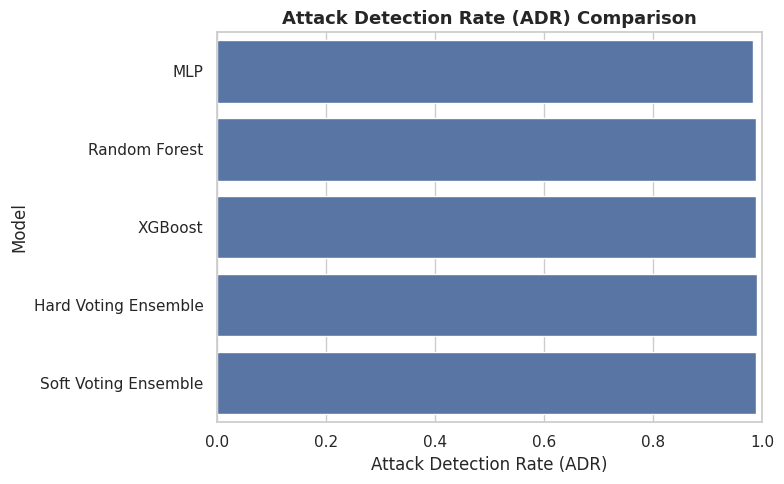


Saved files:
/content/hybrid_ids_outputs_unsw_nb15/hybrid_selected_features.csv
/content/hybrid_ids_outputs_unsw_nb15/train_ais_scores.csv
/content/hybrid_ids_outputs_unsw_nb15/hybrid_ensemble_predictions.csv
/content/hybrid_ids_outputs_unsw_nb15/model_results_summary.csv
/content/hybrid_ids_outputs_unsw_nb15/adr_summary.csv
/content/hybrid_ids_outputs_unsw_nb15/pso_feature_importance.csv


In [4]:
# =========================================================
# Step 4: Basic Cleaning for UNSW-NB15
# =========================================================
optional_drop_cols = ['id']
for col in optional_drop_cols:
    if col in train_df.columns:
        train_df = train_df.drop(columns=[col])
    if col in test_df.columns:
        test_df = test_df.drop(columns=[col])

# Drop attack_cat to avoid leakage in binary pipeline
if 'attack_cat' in train_df.columns:
    train_df = train_df.drop(columns=['attack_cat'])
if 'attack_cat' in test_df.columns:
    test_df = test_df.drop(columns=['attack_cat'])

if 'label' not in train_df.columns or 'label' not in test_df.columns:
    raise ValueError("UNSW-NB15 dataset must contain a 'label' column.")

train_df['label'] = pd.to_numeric(train_df['label'], errors='coerce')
test_df['label'] = pd.to_numeric(test_df['label'], errors='coerce')

train_df = train_df.dropna(subset=['label']).reset_index(drop=True)
test_df = test_df.dropna(subset=['label']).reset_index(drop=True)

train_df['label'] = train_df['label'].astype(int)
test_df['label'] = test_df['label'].astype(int)

# Binary label already exists in UNSW-NB15
# normal = 0, attack = 1
train_df['binary_label'] = train_df['label']
test_df['binary_label'] = test_df['label']

print("\nTrain binary distribution:")
print(train_df['binary_label'].value_counts())

print("\nTest binary distribution:")
print(test_df['binary_label'].value_counts())

# =========================================================
# Step 5: Encode Categorical Features
# =========================================================
categorical_cols = ['proto', 'service', 'state']
existing_cat_cols = [col for col in categorical_cols if col in train_df.columns]

combined_df = pd.concat(
    [train_df.drop(columns=['binary_label']), test_df.drop(columns=['binary_label'])],
    axis=0
).reset_index(drop=True)

for col in existing_cat_cols:
    le = LabelEncoder()
    combined_df[col] = le.fit_transform(combined_df[col].astype(str))

train_processed = combined_df.iloc[:len(train_df)].copy()
test_processed = combined_df.iloc[len(train_df):].copy()

# =========================================================
# Step 6: Separate Features and Labels
# =========================================================
X_train_full = train_processed.drop(columns=['label'])
X_test_full = test_processed.drop(columns=['label'])

y_train_full = train_df['binary_label'].values
y_test = test_df['binary_label'].values

X_train_full = X_train_full.select_dtypes(include=[np.number]).copy()
X_test_full = X_test_full.select_dtypes(include=[np.number]).copy()

# =========================================================
# Step 6.1: Remove Infinite and Missing Values
# =========================================================
X_train_full = X_train_full.replace([np.inf, -np.inf], np.nan)
X_test_full = X_test_full.replace([np.inf, -np.inf], np.nan)

train_mask = ~X_train_full.isna().any(axis=1)
test_mask = ~X_test_full.isna().any(axis=1)

X_train_full = X_train_full[train_mask]
y_train_full = y_train_full[train_mask]

X_test_full = X_test_full[test_mask]
y_test = y_test[test_mask]

# =========================================================
# Step 7: Standardization (Z-score)
# =========================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_test_scaled = scaler.transform(X_test_full)

X_train_full = pd.DataFrame(X_train_scaled, columns=X_train_full.columns)
X_test_full = pd.DataFrame(X_test_scaled, columns=X_test_full.columns)

# =========================================================
# Step 8: Train / Validation Split
# =========================================================
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full
)

X_train = X_train.reset_index(drop=True)
X_val = X_val.reset_index(drop=True)
X_test_full = X_test_full.reset_index(drop=True)

print("\nTrain:", X_train.shape)
print("Val  :", X_val.shape)
print("Test :", X_test_full.shape)

# =========================================================
# Step 8.5: Apply SMOTE + Tomek Links
# =========================================================
print("\nApplying SMOTE + Tomek Links on training set...")

class_counts = Counter(y_train)
print("Class counts before SMOTETomek:")
print(class_counts)

min_class_size = min(class_counts.values())

if min_class_size < 2:
    raise ValueError(
        f"At least one class has only {min_class_size} sample. "
        f"SMOTE cannot work. Remove ultra-rare classes first."
    )

safe_k_neighbors = min(5, min_class_size - 1)
print("Using SMOTE k_neighbors =", safe_k_neighbors)

smote = SMOTE(
    k_neighbors=safe_k_neighbors,
    random_state=42
)

smote_tomek = SMOTETomek(
    smote=smote,
    random_state=42
)

X_train_res, y_train_res = smote_tomek.fit_resample(X_train, y_train)

print("Before SMOTETomek:", X_train.shape, len(y_train))
print("After  SMOTETomek:", X_train_res.shape, len(y_train_res))
print("Class counts after SMOTETomek:")
print(Counter(y_train_res))

X_train = pd.DataFrame(X_train_res, columns=X_train.columns)
y_train = np.asarray(y_train_res)

# =========================================================
# Step 9: Balanced Subset for PSO
# =========================================================
def create_balanced_subset(X, y, samples_per_class=4000):
    normal_idx = np.where(y == 0)[0]
    attack_idx = np.where(y == 1)[0]

    n_normal = min(len(normal_idx), samples_per_class)
    n_attack = min(len(attack_idx), samples_per_class)

    chosen_normal = np.random.choice(normal_idx, n_normal, replace=False)
    chosen_attack = np.random.choice(attack_idx, n_attack, replace=False)

    chosen_idx = np.concatenate([chosen_normal, chosen_attack])
    np.random.shuffle(chosen_idx)

    X_sub = X.iloc[chosen_idx].reset_index(drop=True)
    y_sub = y[chosen_idx]
    return X_sub, y_sub

X_pso, y_pso = create_balanced_subset(X_train, y_train, samples_per_class=4000)

# =========================================================
# Step 10: PSO Feature Selection using RF Fitness
# =========================================================
X_pso_np = X_pso.values
X_val_np = X_val.values

def fitness_function(particle, X_train_sub, X_val_full, y_train_sub, y_val, alpha=0.97):
    selected = np.where(particle == 1)[0]

    if len(selected) == 0:
        return 0.0

    Xtr = X_train_sub[:, selected]
    Xv = X_val_full[:, selected]

    clf = RandomForestClassifier(
        n_estimators=120,
        random_state=42,
        n_jobs=-1
    )
    clf.fit(Xtr, y_train_sub)
    preds = clf.predict(Xv)

    bal_acc = balanced_accuracy_score(y_val, preds)
    feature_ratio = len(selected) / X_train_sub.shape[1]
    fitness = alpha * bal_acc + (1 - alpha) * (1 - feature_ratio)
    return fitness

num_features = X_pso_np.shape[1]
num_particles = 20
num_iterations = 25
w, c1, c2 = 0.72, 1.49, 1.49

particles = np.random.randint(0, 2, size=(num_particles, num_features))
velocities = np.random.uniform(-1, 1, size=(num_particles, num_features))

for i in range(num_particles):
    if particles[i].sum() == 0:
        particles[i, np.random.randint(0, num_features)] = 1

pbest_positions = particles.copy()
pbest_scores = np.zeros(num_particles)
gbest_position = None
gbest_score = -1
gbest_history = []

for i in range(num_particles):
    score = fitness_function(particles[i], X_pso_np, X_val_np, y_pso, y_val)
    pbest_scores[i] = score
    if score > gbest_score:
        gbest_score = score
        gbest_position = particles[i].copy()

print("\nStarting PSO...")
for iteration in range(num_iterations):
    for i in range(num_particles):
        r1 = np.random.rand(num_features)
        r2 = np.random.rand(num_features)

        velocities[i] = (
            w * velocities[i]
            + c1 * r1 * (pbest_positions[i] - particles[i])
            + c2 * r2 * (gbest_position - particles[i])
        )

        sigmoid = 1 / (1 + np.exp(-velocities[i]))
        particles[i] = (np.random.rand(num_features) < sigmoid).astype(int)

        if particles[i].sum() == 0:
            particles[i, np.random.randint(0, num_features)] = 1

        score = fitness_function(particles[i], X_pso_np, X_val_np, y_pso, y_val)

        if score > pbest_scores[i]:
            pbest_scores[i] = score
            pbest_positions[i] = particles[i].copy()

        if score > gbest_score:
            gbest_score = score
            gbest_position = particles[i].copy()

    gbest_history.append(gbest_score)
    print(f"Iteration {iteration + 1}/{num_iterations}, Best Fitness: {gbest_score:.4f}")

selected_feature_indices = np.where(gbest_position == 1)[0]
selected_feature_names = X_train.columns[selected_feature_indices]

print("\nSelected feature count:", len(selected_feature_indices))
print("Selected features:", list(selected_feature_names))

X_train_sel = X_train.values[:, selected_feature_indices]
X_val_sel = X_val.values[:, selected_feature_indices]
X_test_sel = X_test_full.values[:, selected_feature_indices]

# =========================================================
# Step 11: Balanced AIS Training Data
# =========================================================
def create_balanced_numpy_subset(X, y, normal_count=5000, attack_count=5000):
    normal_idx = np.where(y == 0)[0]
    attack_idx = np.where(y == 1)[0]

    n_normal = min(len(normal_idx), normal_count)
    n_attack = min(len(attack_idx), attack_count)

    chosen_normal = np.random.choice(normal_idx, n_normal, replace=False)
    chosen_attack = np.random.choice(attack_idx, n_attack, replace=False)

    return X[chosen_normal], X[chosen_attack]

self_samples, attack_samples = create_balanced_numpy_subset(
    X_train_sel, y_train, normal_count=5000, attack_count=5000
)

print("\nSelf samples :", self_samples.shape)
print("Attack samples:", attack_samples.shape)

# =========================================================
# Step 12: Negative Selection Detector Generation
# =========================================================
def generate_attack_detectors(self_samples, attack_samples, num_detectors=600, min_self_distance=0.6):
    detectors = []
    attempts = 0
    max_attempts = num_detectors * 100

    while len(detectors) < num_detectors and attempts < max_attempts:
        base = attack_samples[np.random.randint(0, len(attack_samples))].copy()
        candidate = base + np.random.normal(0, 0.08, size=base.shape)

        d_self = np.min(np.linalg.norm(self_samples - candidate, axis=1))

        if d_self >= min_self_distance:
            detectors.append(candidate)

        attempts += 1

    return np.array(detectors)

detectors = generate_attack_detectors(
    self_samples=self_samples,
    attack_samples=attack_samples,
    num_detectors=1000,
    min_self_distance=0.6
)

print("\nDetector shape:", detectors.shape)

# =========================================================
# Step 13: Create AIS Anomaly Features
# =========================================================
def create_ais_scores(X, detectors):
    feature_list = []

    for sample in X:
        dists = np.linalg.norm(detectors - sample, axis=1)
        sorted_dists = np.sort(dists)

        min_dist = np.min(dists)
        mean_dist = np.mean(dists)
        std_dist = np.std(dists)
        median_dist = np.median(dists)

        closest3_mean = np.mean(sorted_dists[:3]) if len(sorted_dists) >= 3 else np.mean(sorted_dists)
        closest5_mean = np.mean(sorted_dists[:5]) if len(sorted_dists) >= 5 else np.mean(sorted_dists)
        closest10_mean = np.mean(sorted_dists[:10]) if len(sorted_dists) >= 10 else np.mean(sorted_dists)

        activated_08 = np.sum(dists <= 0.8)
        activated_10 = np.sum(dists <= 1.0)
        activated_15 = np.sum(dists <= 1.5)

        affinities = 1 / (1 + dists)
        max_affinity = np.max(affinities)
        mean_affinity = np.mean(affinities)
        std_affinity = np.std(affinities)

        feature_list.append([
            min_dist,
            mean_dist,
            std_dist,
            median_dist,
            closest3_mean,
            closest5_mean,
            closest10_mean,
            activated_08,
            activated_10,
            activated_15,
            max_affinity,
            mean_affinity,
            std_affinity
        ])

    return np.array(feature_list)

X_train_ais = create_ais_scores(X_train_sel, detectors)
X_val_ais = create_ais_scores(X_val_sel, detectors)
X_test_ais = create_ais_scores(X_test_sel, detectors)

print("\nAIS feature shape (train):", X_train_ais.shape)

# =========================================================
# Step 14: Merge Selected Features + AIS Features
# =========================================================
X_train_hybrid = np.hstack((X_train_sel, X_train_ais))
X_val_hybrid = np.hstack((X_val_sel, X_val_ais))
X_test_hybrid = np.hstack((X_test_sel, X_test_ais))

print("Hybrid train shape:", X_train_hybrid.shape)
print("Hybrid val shape  :", X_val_hybrid.shape)
print("Hybrid test shape :", X_test_hybrid.shape)

# =========================================================
# Step 15: Evaluation + Visualization Helpers
# =========================================================
results_summary = []

def compute_metrics(y_true, y_pred, y_prob):
    cm = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm.ravel()

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    bal_acc = balanced_accuracy_score(y_true, y_pred)

    fpr = FP / (FP + TN) if (FP + TN) > 0 else 0
    tnr = TN / (TN + FP) if (TN + FP) > 0 else 0
    adr = TP / (TP + FN) if (TP + FN) > 0 else 0   # Attack Detection Rate

    fpr_curve, tpr_curve, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr_curve, tpr_curve)

    precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = auc(recall_curve, precision_curve)

    return {
        'cm': cm,
        'TN': TN, 'FP': FP, 'FN': FN, 'TP': TP,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'balanced_accuracy': bal_acc,
        'fpr': fpr,
        'tnr': tnr,
        'adr': adr,
        'roc_fpr': fpr_curve,
        'roc_tpr': tpr_curve,
        'roc_auc': roc_auc,
        'pr_precision': precision_curve,
        'pr_recall': recall_curve,
        'pr_auc': pr_auc
    }

def print_metrics(name, metrics_dict):
    print(f"\n{'='*70}")
    print(name)
    print(f"{'='*70}")
    print(f"Accuracy              : {metrics_dict['accuracy']:.4f}")
    print(f"Precision             : {metrics_dict['precision']:.4f}")
    print(f"Recall                : {metrics_dict['recall']:.4f}")
    print(f"F1-score              : {metrics_dict['f1']:.4f}")
    print(f"Balanced Accuracy     : {metrics_dict['balanced_accuracy']:.4f}")
    print(f"Attack Detection Rate : {metrics_dict['adr']:.4f}")
    print(f"False Positive Rate   : {metrics_dict['fpr']:.4f}")
    print(f"True Negative Rate    : {metrics_dict['tnr']:.4f}")
    print("\nConfusion Matrix:")
    print(metrics_dict['cm'])

def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Normal', 'Attack'],
        yticklabels=['Normal', 'Attack']
    )
    plt.title(title, fontsize=13, fontweight='bold')
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

def add_results_row(name, metrics_dict):
    results_summary.append({
        'Model': name,
        'Accuracy': metrics_dict['accuracy'],
        'Precision': metrics_dict['precision'],
        'Recall': metrics_dict['recall'],
        'F1-score': metrics_dict['f1'],
        'Balanced Accuracy': metrics_dict['balanced_accuracy'],
        'ADR': metrics_dict['adr'],
        'False Positive Rate': metrics_dict['fpr'],
        'True Negative Rate': metrics_dict['tnr'],
        'ROC-AUC': metrics_dict['roc_auc'],
        'PR-AUC': metrics_dict['pr_auc']
    })

# =========================================================
# Step 16: TensorFlow / GPU Stability Fix
# =========================================================
tf.keras.backend.clear_session()

X_train_hybrid = np.asarray(X_train_hybrid).astype(np.float32)
X_val_hybrid   = np.asarray(X_val_hybrid).astype(np.float32)
X_test_hybrid  = np.asarray(X_test_hybrid).astype(np.float32)

y_train = np.asarray(y_train).astype(np.float32)
y_val   = np.asarray(y_val).astype(np.float32)
y_test  = np.asarray(y_test).astype(np.float32)

print("X_train_hybrid dtype:", X_train_hybrid.dtype)
print("X_val_hybrid dtype  :", X_val_hybrid.dtype)
print("X_test_hybrid dtype :", X_test_hybrid.dtype)
print("y_train dtype:", y_train.dtype)
print("y_val dtype  :", y_val.dtype)
print("y_test dtype :", y_test.dtype)

# =========================================================
# Step 17: Train MLP
# =========================================================
tf.keras.backend.clear_session()

X_train_hybrid = np.asarray(X_train_hybrid).astype(np.float32)
X_val_hybrid   = np.asarray(X_val_hybrid).astype(np.float32)
X_test_hybrid  = np.asarray(X_test_hybrid).astype(np.float32)

y_train = np.asarray(y_train).astype(np.float32)
y_val   = np.asarray(y_val).astype(np.float32)
y_test  = np.asarray(y_test).astype(np.float32)

mlp_model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_hybrid.shape[1],)),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

mlp_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\nMLP MODEL SUMMARY")
mlp_model.summary()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

history = mlp_model.fit(
    X_train_hybrid, y_train,
    validation_data=(X_val_hybrid, y_val),
    epochs=80,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

# =========================================================
# Step 18: Training vs Validation Loss
# =========================================================
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Training vs Validation Loss (MLP)', fontsize=13, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

# =========================================================
# Step 19: Threshold tuning for MLP
# =========================================================
mlp_val_probs = mlp_model.predict(X_val_hybrid).ravel()
candidate_thresholds = np.arange(0.30, 0.71, 0.02)

best_mlp_threshold = 0.50
best_mlp_f1 = -1

for th in candidate_thresholds:
    preds = (mlp_val_probs >= th).astype(int)
    score = f1_score(y_val, preds, zero_division=0)
    if score > best_mlp_f1:
        best_mlp_f1 = score
        best_mlp_threshold = th

print(f"\nBest MLP threshold: {best_mlp_threshold:.2f}")

mlp_test_probs = mlp_model.predict(X_test_hybrid).ravel()
mlp_pred = (mlp_test_probs >= best_mlp_threshold).astype(int)

mlp_metrics = compute_metrics(y_test, mlp_pred, mlp_test_probs)
print_metrics("HYBRID AIS + PSO + MLP", mlp_metrics)
plot_confusion_matrix(mlp_metrics['cm'], "Confusion Matrix - MLP")
add_results_row("MLP", mlp_metrics)

# =========================================================
# Step 20: Train Random Forest
# =========================================================
rf_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_hybrid, y_train)

rf_val_probs = rf_model.predict_proba(X_val_hybrid)[:, 1]
best_rf_threshold = 0.50
best_rf_f1 = -1

for th in candidate_thresholds:
    preds = (rf_val_probs >= th).astype(int)
    score = f1_score(y_val, preds, zero_division=0)
    if score > best_rf_f1:
        best_rf_f1 = score
        best_rf_threshold = th

print(f"Best RF threshold : {best_rf_threshold:.2f}")

rf_test_probs = rf_model.predict_proba(X_test_hybrid)[:, 1]
rf_pred = (rf_test_probs >= best_rf_threshold).astype(int)

rf_metrics = compute_metrics(y_test, rf_pred, rf_test_probs)
print_metrics("HYBRID AIS + PSO + RANDOM FOREST", rf_metrics)
plot_confusion_matrix(rf_metrics['cm'], "Confusion Matrix - Random Forest")
add_results_row("Random Forest", rf_metrics)

# =========================================================
# Step 21: Train XGBoost
# =========================================================
xgb_model = XGBClassifier(
    n_estimators=900,
    max_depth=10,
    learning_rate=0.03,
    subsample=0.90,
    colsample_bytree=0.90,
    gamma=0.1,
    min_child_weight=2,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_hybrid, y_train,
    eval_set=[(X_val_hybrid, y_val)],
    verbose=False
)

xgb_val_probs = xgb_model.predict_proba(X_val_hybrid)[:, 1]
best_xgb_threshold = 0.50
best_xgb_f1 = -1

for th in candidate_thresholds:
    preds = (xgb_val_probs >= th).astype(int)
    score = f1_score(y_val, preds, zero_division=0)
    if score > best_xgb_f1:
        best_xgb_f1 = score
        best_xgb_threshold = th

print(f"Best XGB threshold: {best_xgb_threshold:.2f}")

xgb_test_probs = xgb_model.predict_proba(X_test_hybrid)[:, 1]
xgb_pred = (xgb_test_probs >= best_xgb_threshold).astype(int)

xgb_metrics = compute_metrics(y_test, xgb_pred, xgb_test_probs)
print_metrics("HYBRID AIS + PSO + XGBOOST", xgb_metrics)
plot_confusion_matrix(xgb_metrics['cm'], "Confusion Matrix - XGBoost")
add_results_row("XGBoost", xgb_metrics)

# =========================================================
# Step 22: Ensemble Voting (Hard)
# =========================================================
ensemble_votes = mlp_pred + rf_pred + xgb_pred
ensemble_pred = (ensemble_votes >= 2).astype(int)

hard_vote_probs = (mlp_test_probs + rf_test_probs + xgb_test_probs) / 3.0

ensemble_metrics = compute_metrics(y_test, ensemble_pred, hard_vote_probs)
print_metrics("HYBRID AIS + PSO + ENSEMBLE VOTING", ensemble_metrics)
plot_confusion_matrix(ensemble_metrics['cm'], "Confusion Matrix - Hard Voting Ensemble")
add_results_row("Hard Voting Ensemble", ensemble_metrics)

# =========================================================
# Step 23: Soft Voting
# =========================================================
soft_probs = (
    0.15 * mlp_test_probs +
    0.30 * rf_test_probs +
    0.55 * xgb_test_probs
)

best_soft_threshold = 0.50
best_soft_f1 = -1

soft_val_probs = (
    0.15 * mlp_val_probs +
    0.30 * rf_val_probs +
    0.55 * xgb_val_probs
)

for th in candidate_thresholds:
    preds = (soft_val_probs >= th).astype(int)
    score = f1_score(y_val, preds, zero_division=0)
    if score > best_soft_f1:
        best_soft_f1 = score
        best_soft_threshold = th

print(f"\nBest Soft Voting threshold: {best_soft_threshold:.2f}")

soft_ensemble_pred = (soft_probs >= best_soft_threshold).astype(int)

soft_metrics = compute_metrics(y_test, soft_ensemble_pred, soft_probs)
print_metrics("HYBRID AIS + PSO + SOFT VOTING ENSEMBLE", soft_metrics)
plot_confusion_matrix(soft_metrics['cm'], "Confusion Matrix - Soft Voting Ensemble")
add_results_row("Soft Voting Ensemble", soft_metrics)

# =========================================================
# Step 24: ROC Curve (All Models)
# =========================================================
plt.figure(figsize=(8, 6))
plt.plot(mlp_metrics['roc_fpr'], mlp_metrics['roc_tpr'], label=f"MLP (AUC={mlp_metrics['roc_auc']:.4f})", linewidth=2)
plt.plot(rf_metrics['roc_fpr'], rf_metrics['roc_tpr'], label=f"RF (AUC={rf_metrics['roc_auc']:.4f})", linewidth=2)
plt.plot(xgb_metrics['roc_fpr'], xgb_metrics['roc_tpr'], label=f"XGB (AUC={xgb_metrics['roc_auc']:.4f})", linewidth=2)
plt.plot(ensemble_metrics['roc_fpr'], ensemble_metrics['roc_tpr'], label=f"Hard Ensemble (AUC={ensemble_metrics['roc_auc']:.4f})", linewidth=2)
plt.plot(soft_metrics['roc_fpr'], soft_metrics['roc_tpr'], label=f"Soft Ensemble (AUC={soft_metrics['roc_auc']:.4f})", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', linewidth=1)
plt.title("ROC Curve - All Models", fontsize=13, fontweight='bold')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

# =========================================================
# Step 25: Precision-Recall Curve (All Models)
# =========================================================
plt.figure(figsize=(8, 6))
plt.plot(mlp_metrics['pr_recall'], mlp_metrics['pr_precision'], label=f"MLP (AUC={mlp_metrics['pr_auc']:.4f})", linewidth=2)
plt.plot(rf_metrics['pr_recall'], rf_metrics['pr_precision'], label=f"RF (AUC={rf_metrics['pr_auc']:.4f})", linewidth=2)
plt.plot(xgb_metrics['pr_recall'], xgb_metrics['pr_precision'], label=f"XGB (AUC={xgb_metrics['pr_auc']:.4f})", linewidth=2)
plt.plot(ensemble_metrics['pr_recall'], ensemble_metrics['pr_precision'], label=f"Hard Ensemble (AUC={ensemble_metrics['pr_auc']:.4f})", linewidth=2)
plt.plot(soft_metrics['pr_recall'], soft_metrics['pr_precision'], label=f"Soft Ensemble (AUC={soft_metrics['pr_auc']:.4f})", linewidth=2)
plt.title("Precision-Recall Curve - All Models", fontsize=13, fontweight='bold')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()

# =========================================================
# Step 26: Feature Importance from PSO
# =========================================================
selected_mask = np.zeros(num_features)
selected_mask[selected_feature_indices] = 1

pso_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Selected_by_PSO': selected_mask.astype(int)
}).sort_values(by='Selected_by_PSO', ascending=False)

top_selected_features = pd.DataFrame({
    'Feature': selected_feature_names,
    'Selection_Order': np.arange(1, len(selected_feature_names) + 1)
})

plt.figure(figsize=(10, max(5, len(selected_feature_names) * 0.25)))
sns.barplot(
    data=top_selected_features,
    y='Feature',
    x='Selection_Order',
    orient='h'
)
plt.title("Feature Importance from PSO (Selected Features)", fontsize=13, fontweight='bold')
plt.xlabel("Selection Rank")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# =========================================================
# Step 27: PSO Fitness Convergence Curve
# =========================================================
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(gbest_history) + 1), gbest_history, linewidth=2)
plt.title("PSO Fitness Convergence", fontsize=13, fontweight='bold')
plt.xlabel("Iteration")
plt.ylabel("Best Fitness")
plt.tight_layout()
plt.show()

# =========================================================
# Step 28: Results Summary Table
# =========================================================
results_df = pd.DataFrame(results_summary)
print("\nFINAL RESULTS SUMMARY")
print(results_df.round(4))

# =========================================================
# Step 29: Attack Detection Rate (ADR) Summary at the End
# =========================================================
adr_summary_df = pd.DataFrame({
    'Model': results_df['Model'],
    'Attack Detection Rate (ADR)': results_df['ADR']
})

print("\n" + "="*60)
print("ATTACK DETECTION RATE (ADR) SUMMARY")
print("="*60)
print(adr_summary_df.round(4))

plt.figure(figsize=(8, 5))
sns.barplot(data=adr_summary_df, x='Attack Detection Rate (ADR)', y='Model')
plt.title("Attack Detection Rate (ADR) Comparison", fontsize=13, fontweight='bold')
plt.xlim(0, 1.0)
plt.tight_layout()
plt.show()

# =========================================================
# Step 30: Save Results
# =========================================================
output_dir = '/content/hybrid_ids_outputs_unsw_nb15'
os.makedirs(output_dir, exist_ok=True)

selected_features_df = pd.DataFrame({
    "Selected_Features": selected_feature_names
})
selected_features_df.to_csv(f'{output_dir}/hybrid_selected_features.csv', index=False)

ais_feature_names = [
    'min_dist', 'mean_dist', 'std_dist', 'median_dist',
    'closest3_mean', 'closest5_mean', 'closest10_mean',
    'activated_08', 'activated_10', 'activated_15',
    'max_affinity', 'mean_affinity', 'std_affinity'
]

train_ais_df = pd.DataFrame(X_train_ais, columns=ais_feature_names)
train_ais_df.to_csv(f'{output_dir}/train_ais_scores.csv', index=False)

pred_df = pd.DataFrame({
    'Actual': y_test,
    'MLP_Prob': mlp_test_probs,
    'MLP_Pred': mlp_pred,
    'RF_Prob': rf_test_probs,
    'RF_Pred': rf_pred,
    'XGB_Prob': xgb_test_probs,
    'XGB_Pred': xgb_pred,
    'Hard_Ensemble_Pred': ensemble_pred,
    'Soft_Prob': soft_probs,
    'Soft_Ensemble_Pred': soft_ensemble_pred
})
pred_df.to_csv(f'{output_dir}/hybrid_ensemble_predictions.csv', index=False)

results_df.to_csv(f'{output_dir}/model_results_summary.csv', index=False)
adr_summary_df.to_csv(f'{output_dir}/adr_summary.csv', index=False)
pso_importance_df.to_csv(f'{output_dir}/pso_feature_importance.csv', index=False)

print("\nSaved files:")
print(f"{output_dir}/hybrid_selected_features.csv")
print(f"{output_dir}/train_ais_scores.csv")
print(f"{output_dir}/hybrid_ensemble_predictions.csv")
print(f"{output_dir}/model_results_summary.csv")
print(f"{output_dir}/adr_summary.csv")
print(f"{output_dir}/pso_feature_importance.csv")